# Obiettivo

In questa nuova pipeline non costruiamo un modello da zero, ma partiamo dalla versione migliorata già ottenuta nel progetto precedente per introdurre ulteriori miglioramenti mirati.

L’obiettivo è aumentare la capacità del modello di generalizzare meglio su immagini mai viste, ridurre l’overfitting e migliorare la distinzione tra classi che tendono a confondersi più facilmente, come **cat e dog**, **bird e deer**, oppure **automobile e truck**.

Per raggiungere questo obiettivo introdurremo quattro miglioramenti principali.

Il primo sarà il potenziamento della **data augmentation**, aggiungendo non solo trasformazioni geometriche leggere come flip, rotazioni e traslazioni, ma anche piccole variazioni di **luminosità**, **contrasto** e, se possibile, di **colore/saturazione**. Questo servirà a rendere il modello meno sensibile alle condizioni di luce e alle differenze cromatiche specifiche del training set.

Il secondo miglioramento sarà la sostituzione di **Flatten** con **GlobalAveragePooling2D**. Questa modifica permette di ridurre il numero di parametri nella parte finale della rete, limitando il rischio di overfitting e rendendo l’architettura più compatta e moderna.

Il terzo miglioramento sarà l’aggiunta di un **blocco convoluzionale aggiuntivo** nella parte più profonda della rete. In questo modo il modello potrà estrarre feature più ricche e più astratte, utili soprattutto per distinguere immagini simili tra loro.

Infine, dopo aver costruito questa nuova base architetturale, useremo **Optuna** per il tuning automatico degli iperparametri. L’idea non è cambiare casualmente il modello, ma cercare in modo sistematico la combinazione di parametri che porta alle migliori prestazioni in validazione.

L’ordine seguito sarà quindi questo:
1. costruzione della nuova CNN migliorata;
2. addestramento e prima valutazione della nuova architettura;
3. tuning automatico con Optuna;
4. confronto finale con il modello precedente.

In questo modo sarà possibile capire non solo **se** il modello migliora, ma anche **quali modifiche** hanno contribuito di più al risultato finale.

# Import librerie

Oltre agli strumenti già usati nella pipeline precedente, qui aggiungiamo anche i componenti che serviranno per:
- introdurre augmentation più ricca sulle immagini;
- costruire un’architettura più avanzata;
- tracciare grafici utili per interpretare il comportamento del modello;
- eseguire il tuning automatico degli iperparametri.

L’idea è quindi preparare fin da subito un ambiente completo, così da non dover aggiungere import in modo frammentato nelle sezioni successive.

In [ ]:
!pip install optuna

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import platform
import sys

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

## Setup GPU

In [ ]:
# Setup GPU TensorFlow
print("Keras backend:", keras.backend.backend())
print("TensorFlow version:", tf.__version__)
print("Sistema:", platform.platform())
print("Python:", sys.version.split()[0])

gpus = tf.config.list_physical_devices("GPU")
print("GPU fisiche rilevate:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices("GPU")
        print("GPU logiche:", logical_gpus)
        print("Memory growth abilitata correttamente.")
    except RuntimeError as e:
        print("Errore durante il setup GPU:", e)
else:
    print("Nessuna GPU rilevata da TensorFlow.")

Keras backend: tensorflow
TensorFlow version: 2.19.0
Sistema: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.12
GPU fisiche rilevate: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU logiche: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Memory growth abilitata correttamente.


# 1. Caricamento del dataset

Poiché il dataset è lo stesso della pipeline precedente, questa fase non cambia dal punto di vista dei dati di partenza. Quello che cambia è il modo in cui useremo queste immagini nelle fasi successive, grazie a una pipeline di augmentation più ricca e a un modello più avanzato.

Facciamo anche una prima verifica delle dimensioni degli array, così da confermare che il caricamento sia avvenuto correttamente.

In [ ]:
# Caricamento del dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Nomi delle classi
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Controllo delle shape
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("\nNumero classi:", len(class_names))
print("Classi:", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)

Numero classi: 10
Classi: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1.1. Visualizzazione di prova delle immagini

Prima di allenare il modello è utile osservare visivamente alcune immagini per capire la varietà del dataset e la difficoltà del compito.


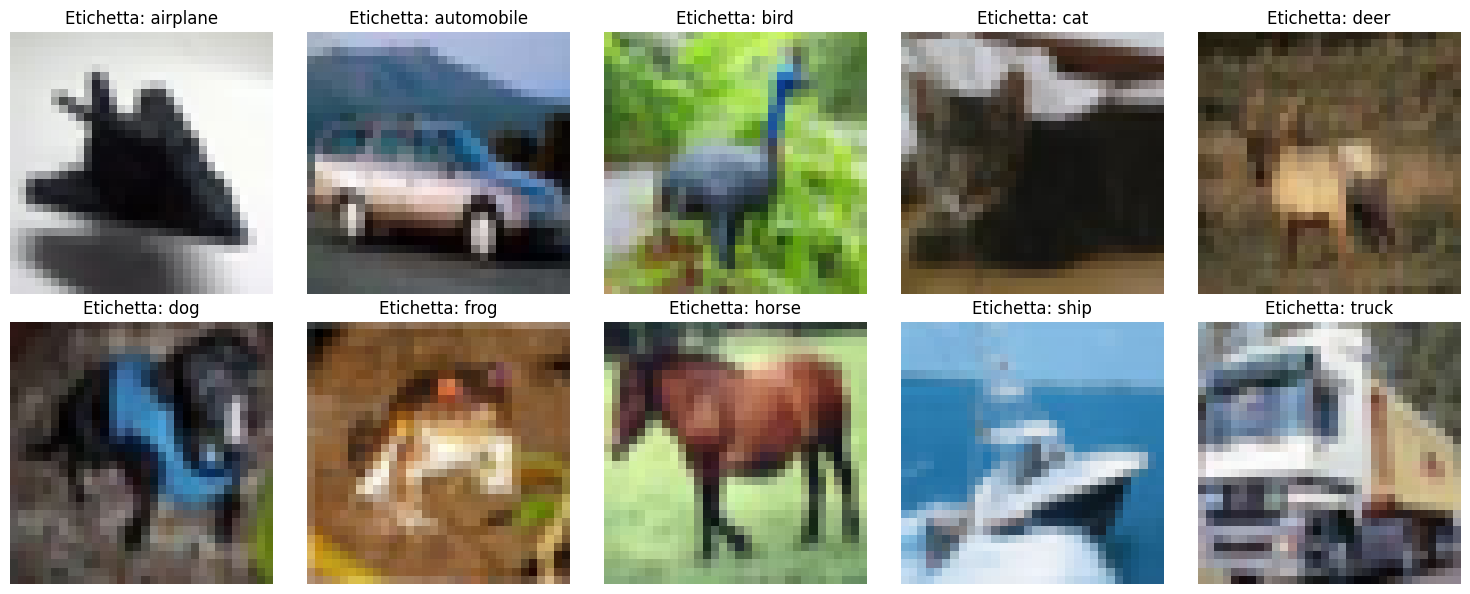

In [ ]:
plt.figure(figsize=(15, 6))

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for class_index, class_name in enumerate(class_names):
    img_index = np.where(y_train.squeeze() == class_index)[0][0]

    plt.subplot(2, 5, class_index + 1)
    plt.imshow(x_train[img_index])
    plt.title(f'Etichetta: {class_name}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 2. Preprocessing

Il preprocessing serve a preparare i dati in una forma più adatta all’addestramento della rete neurale.

Anche in questa pipeline manteniamo i passaggi fondamentali già usati in precedenza, perché restano corretti anche per il nuovo modello. In particolare:
- normalizziamo i pixel dividendo per 255, così i valori passano dall’intervallo **[0, 255]** all’intervallo **[0, 1]**;
- convertiamo le etichette in formato **one-hot encoding**, così il modello potrà produrre una probabilità per ciascuna delle 10 classi.

La normalizzazione è importante perché rende il training più stabile e facilita l’ottimizzazione.  
La codifica one-hot, invece, è necessaria per usare correttamente la classificazione multiclasse con output finale softmax.

In questa sezione facciamo anche un piccolo controllo visivo per mostrare che la normalizzazione non cambia il contenuto dell’immagine, ma solo la scala numerica dei pixel.

In [ ]:
# Conversione delle etichette in one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalizzazione dei pixel
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Controllo  delle shape
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("Esempio label one-hot :", y_train[0])

x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)
y_train shape: (50000, 10)
y_test shape : (10000, 10)
Esempio label one-hot : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


# 3. Tuning automatico con Optuna

Introduciamo **Optuna**, una libreria per l’ottimizzazione automatica degli iperparametri.  
L’idea è semplice: invece di scegliere manualmente i parametri del modello, lasciamo che Optuna provi diverse combinazioni e misuri quali funzionano meglio sul validation set.

In questa fase non stiamo ancora cercando il modello finale definitivo, ma stiamo cercando la **migliore configurazione di partenza** per:
- numero di filtri nei blocchi convoluzionali;
- dropout dei vari blocchi;
- numero di neuroni del classificatore finale;
- learning rate.

Ogni configurazione viene addestrata per poche epoche, in modo da confrontare rapidamente le varie soluzioni.  
Alla fine, Optuna ci restituirà la combinazione di iperparametri più promettente, che useremo per costruire e addestrare il modello finale in modo completo.


In [ ]:
from sklearn.model_selection import train_test_split

# Split fisso per il tuning con Optuna
x_train_opt, x_val_opt, y_train_opt, y_val_opt = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("x_train_opt shape:", x_train_opt.shape)
print("x_val_opt shape  :", x_val_opt.shape)
print("y_train_opt shape:", y_train_opt.shape)
print("y_val_opt shape  :", y_val_opt.shape)

x_train_opt shape: (45000, 32, 32, 3)
x_val_opt shape  : (5000, 32, 32, 3)
y_train_opt shape: (45000, 10)
y_val_opt shape  : (5000, 10)


## 3.1 Definizione del modello parametrico

Per usare Optuna dobbiamo costruire una funzione capace di generare il modello in modo dinamico.

In pratica, invece di fissare a mano tutti i valori, lasciamo che alcuni parametri vengano scelti automaticamente da Optuna all’interno di un certo intervallo.

In questa nuova versione rendiamo ottimizzabili:
- il numero di filtri nei blocchi convoluzionali;
- i tassi di dropout;
- la dimensione del classificatore finale;
- il learning rate.

La struttura generale della rete resta comunque coerente con la nostra nuova base:
- data augmentation;
- blocchi convoluzionali con Batch Normalization e Dropout;
- blocco convoluzionale aggiuntivo;
- GlobalAveragePooling2D al posto di Flatten.

In questo modo Optuna non costruisce modelli casuali, ma esplora varianti sensate della stessa architettura.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

# Layer personalizzato per color space augmentation leggera
class ColorJitter(tf.keras.layers.Layer):
    def __init__(self, brightness=0.08, contrast=0.12, saturation=0.10, **kwargs):
        super().__init__(**kwargs)
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def call(self, images, training=None):
        if training is False:
            return images

        images = tf.image.random_brightness(images, max_delta=self.brightness)
        images = tf.image.random_contrast(
            images,
            lower=1.0 - self.contrast,
            upper=1.0 + self.contrast
        )
        images = tf.image.random_saturation(
            images,
            lower=1.0 - self.saturation,
            upper=1.0 + self.saturation
        )
        images = tf.clip_by_value(images, 0.0, 1.0)
        return images

# Data augmentation migliorata
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    ColorJitter(brightness=0.08, contrast=0.12, saturation=0.10)
], name="data_augmentation")


def build_model(trial):
    filters_1 = trial.suggest_categorical("filters_1", [32, 48, 64])
    filters_2 = trial.suggest_categorical("filters_2", [64, 96, 128])
    filters_3 = trial.suggest_categorical("filters_3", [128, 160, 192])
    filters_4 = trial.suggest_categorical("filters_4", [192, 224, 256])

    dropout_1 = trial.suggest_float("dropout_1", 0.20, 0.35)
    dropout_2 = trial.suggest_float("dropout_2", 0.25, 0.40)
    dropout_3 = trial.suggest_float("dropout_3", 0.30, 0.45)
    dropout_4 = trial.suggest_float("dropout_4", 0.35, 0.50)
    dropout_dense = trial.suggest_float("dropout_dense", 0.30, 0.50)

    dense_units = trial.suggest_categorical("dense_units", [64, 128, 192, 256])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)

    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Data augmentation migliorata
        data_augmentation,

        # Blocco 1
        Conv2D(filters_1, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(filters_1, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(dropout_1),

        # Blocco 2
        Conv2D(filters_2, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(filters_2, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(dropout_2),

        # Blocco 3
        Conv2D(filters_3, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(filters_3, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(dropout_3),

        # Blocco 4 aggiuntivo
        Conv2D(filters_4, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(filters_4, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(dropout_4),

        # Parte finale compatta
        GlobalAveragePooling2D(),
        Dense(dense_units, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_dense),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 3.2 Funzione objective di Optuna

La funzione `objective` è il cuore del tuning automatico.

Per ogni trial, Optuna:
- sceglie una combinazione di iperparametri;
- costruisce un nuovo modello con quei valori;
- lo addestra per un numero limitato di epoche;
- misura la validation accuracy;
- usa questo risultato per decidere quali configurazioni esplorare dopo.

In questa fase il training deve essere più corto rispetto a quello finale, perché il suo scopo non è ottenere subito il miglior modello possibile, ma confrontare rapidamente molte configurazioni diverse.

Per questo usiamo:
- poche epoche;
- EarlyStopping;
- ReduceLROnPlateau;
- validation set fisso.

Il valore restituito sarà la **migliore validation accuracy** raggiunta nel trial.

In [ ]:
def objective(trial):
    keras.backend.clear_session()

    model = build_model(trial)

    early_stop_optuna = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    reduce_lr_optuna = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    history = model.fit(
        x_train_opt,
        y_train_opt,
        validation_data=(x_val_opt, y_val_opt),
        epochs=12,
        batch_size=128,
        callbacks=[early_stop_optuna, reduce_lr_optuna],
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])
    return best_val_accuracy

# 3.3. Esecuzione dello studio Optuna

Dopo aver definito la funzione `objective`, possiamo avviare lo studio di Optuna.

In questa fase la libreria proverà diverse configurazioni del modello, cambiando automaticamente gli iperparametri definiti in precedenza. Per ogni trial verrà costruita una CNN coerente con la nostra architettura di base, addestrata per un numero limitato di epoche e valutata sul validation set.

L’obiettivo è trovare la combinazione di parametri che massimizza la **validation accuracy**.

Poiché ogni trial richiede comunque un addestramento, il numero totale di prove va scelto con equilibrio:
- se i trial sono troppo pochi, la ricerca potrebbe essere superficiale;
- se sono troppi, il tuning rischia di diventare molto costoso in termini di tempo.

Un numero ragionevole può essere ad esempio **30 trial**.

In [ ]:
# Creazione dello studio Optuna
study = optuna.create_study(
    direction="maximize",
    study_name="cifar10_cnn_optimization",
    storage="sqlite:///optuna_cifar10.db",
    load_if_exists=True
)

study.optimize(objective, n_trials=30, catch=(tf.errors.InvalidArgumentError,))

print("Numero di trial completati:", len(study.trials))

[I 2026-03-12 13:55:22,092] Using an existing study with name 'cifar10_cnn_optimization' instead of creating a new one.


Epoch 1/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.2939 - loss: 2.1516 - val_accuracy: 0.2104 - val_loss: 2.7425 - learning_rate: 0.0021
Epoch 2/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.5174 - loss: 1.3328 - val_accuracy: 0.5990 - val_loss: 1.1471 - learning_rate: 0.0021
Epoch 3/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.6071 - loss: 1.1039 - val_accuracy: 0.6402 - val_loss: 1.0894 - learning_rate: 0.0021
Epoch 4/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.6747 - loss: 0.9327 - val_accuracy: 0.6930 - val_loss: 0.9393 - learning_rate: 0.0021
Epoch 5/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7091 - loss: 0.8452 - val_accuracy: 0.7214 - val_loss: 0.8517 - learning_rate: 0.0021
Epoch 6/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7318 - loss: 0.7797 - val_accuracy: 0.7002 - val_loss: 1.0039 - learning_rate: 0.0021
Epoch 7/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7461 - l

[I 2026-03-12 13:59:43,376] Trial 1 finished with value: 0.7946000099182129 and parameters: {'filters_1': 64, 'filters_2': 128, 'filters_3': 160, 'filters_4': 256, 'dropout_1': 0.22348352345825823, 'dropout_2': 0.38026172456168617, 'dropout_3': 0.35202016736783576, 'dropout_4': 0.4582228952823247, 'dropout_dense': 0.42728225378172535, 'dense_units': 256, 'learning_rate': 0.0021297926234004646}. Best is trial 1 with value: 0.7946000099182129.


Epoch 1/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.2173 - loss: 2.5377 - val_accuracy: 0.1076 - val_loss: 4.5001 - learning_rate: 3.1193e-04
Epoch 2/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3668 - loss: 1.7895 - val_accuracy: 0.4638 - val_loss: 1.5036 - learning_rate: 3.1193e-04
Epoch 3/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.4488 - loss: 1.5494 - val_accuracy: 0.5042 - val_loss: 1.5108 - learning_rate: 3.1193e-04
Epoch 4/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.5183 - loss: 1.3673 - val_accuracy: 0.5234 - val_loss: 1.4622 - learning_rate: 3.1193e-04
Epoch 5/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.5541 - loss: 1.2695 - val_accuracy: 0.5220 - val_loss: 1.5563 - learning_rate: 3.1193e-04
Epoch 6/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.5914 - loss: 1.1651 - val_accuracy: 0.6224 - val_loss: 1.1447 - learning_rate: 3.1193e-04
Epoch 7/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/ste

[I 2026-03-12 14:02:57,851] Trial 2 finished with value: 0.729200005531311 and parameters: {'filters_1': 32, 'filters_2': 64, 'filters_3': 192, 'filters_4': 224, 'dropout_1': 0.2518158669102244, 'dropout_2': 0.26843734870217034, 'dropout_3': 0.4151690855428829, 'dropout_4': 0.4625999267701725, 'dropout_dense': 0.46250641437839707, 'dense_units': 64, 'learning_rate': 0.0003119334088200683}. Best is trial 1 with value: 0.7946000099182129.


...

Epoch 1/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.3022 - loss: 2.0545 - val_accuracy: 0.1234 - val_loss: 3.6752 - learning_rate: 0.0020
Epoch 2/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5331 - loss: 1.2886 - val_accuracy: 0.6240 - val_loss: 1.0503 - learning_rate: 0.0020
Epoch 3/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.6281 - loss: 1.0477 - val_accuracy: 0.6164 - val_loss: 1.1895 - learning_rate: 0.0020
Epoch 4/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.6840 - loss: 0.9138 - val_accuracy: 0.5796 - val_loss: 1.5459 - learning_rate: 0.0020
Epoch 5/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.7303 - loss: 0.7841 - val_accuracy: 0.7400 - val_loss: 0.7744 - learning_rate: 9.9798e-04
Epoch 6/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7538 - loss: 0.7106 - val_accuracy: 0.7822 - val_loss: 0.6520 - learning_rate: 9.9798e-04
Epoch 7/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.

[I 2026-03-12 15:43:02,519] Trial 29 finished with value: 0.8299999833106995 and parameters: {'filters_1': 48, 'filters_2': 128, 'filters_3': 160, 'filters_4': 224, 'dropout_1': 0.23618306745148554, 'dropout_2': 0.30915828230947434, 'dropout_3': 0.375182551598918, 'dropout_4': 0.4756103751362907, 'dropout_dense': 0.30030213358656377, 'dense_units': 256, 'learning_rate': 0.0019959519587208147}. Best is trial 12 with value: 0.8443999886512756.


Epoch 1/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.3031 - loss: 2.0526 - val_accuracy: 0.3316 - val_loss: 1.9982 - learning_rate: 0.0023
Epoch 2/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5159 - loss: 1.3442 - val_accuracy: 0.5086 - val_loss: 1.5310 - learning_rate: 0.0023
Epoch 3/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6000 - loss: 1.1181 - val_accuracy: 0.5448 - val_loss: 1.4918 - learning_rate: 0.0023
Epoch 4/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6432 - loss: 0.9998 - val_accuracy: 0.6552 - val_loss: 1.0579 - learning_rate: 0.0023
Epoch 5/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6853 - loss: 0.9036 - val_accuracy: 0.6636 - val_loss: 1.0795 - learning_rate: 0.0023
Epoch 6/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7094 - loss: 0.8488 - val_accuracy: 0.7296 - val_loss: 0.7918 - learning_rate: 0.0023
Epoch 7/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7262 - l

[I 2026-03-12 15:45:57,188] Trial 30 finished with value: 0.7856000065803528 and parameters: {'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'filters_4': 192, 'dropout_1': 0.2150451862725827, 'dropout_2': 0.37416721592854474, 'dropout_3': 0.35086976693932576, 'dropout_4': 0.4446778090542522, 'dropout_dense': 0.3300353026748118, 'dense_units': 256, 'learning_rate': 0.0023215528235073857}. Best is trial 12 with value: 0.8443999886512756.


Numero di trial completati: 31


# Considerazioni sull'ottimizzazione con Optuna

L'ottimizzazione automatica degli iperparametri tramite **Optuna** rappresenta, dal punto di vista teorico e metodologico, una strada molto valida per migliorare le prestazioni del modello. Questo approccio permette infatti di esplorare in modo sistematico diverse configurazioni della rete neurale, come numero di filtri, tassi di dropout, dimensione del livello denso e learning rate, con l'obiettivo di individuare la combinazione più efficace.

Nel progetto è stata quindi predisposta una pipeline compatibile con Optuna, integrata con il training del modello e con il salvataggio degli studi effettuati. Tuttavia, durante le prove pratiche è emerso un limite importante legato alle risorse hardware disponibili. Anche con la GPU correttamente configurata e utilizzata da TensorFlow, il costo computazionale dell'ottimizzazione è risultato molto elevato: già un singolo trial di poche epoche ha richiesto un tempo di esecuzione significativo.

Per questo motivo, pur essendo stata implementata e verificata la correttezza dell'impostazione, **l'ottimizzazione completa con Optuna non è stata portata avanti fino in fondo in questa fase del progetto**. Una ricerca estesa degli iperparametri richiede infatti hardware più performante, oppure tempi di esecuzione molto più lunghi, non compatibili con il contesto operativo attuale.

Di conseguenza, Optuna viene considerato in questo lavoro come **uno sviluppo metodologicamente corretto e potenzialmente molto utile**, ma da perseguire in modo concreto solo in presenza di risorse computazionali adeguate. In questa sede, i passi successivi dello studio proseguono quindi con un approccio più controllato e sostenibile, basato sull'analisi dei modelli costruiti e addestrati direttamente nel notebook.

## 3.4 Migliore configurazione trovata

Anche quando l'ottimizzazione non viene portata a termine con un numero elevato di trial, è comunque possibile leggere la migliore configurazione trovata tra quelle effettivamente eseguite.

Questo passaggio è importante perché permette di osservare:
- il miglior valore di validation accuracy ottenuto durante il tuning;
- i valori degli iperparametri associati a quella prestazione;
- la configurazione che, tra quelle provate, ha mostrato il comportamento più promettente.

In un contesto ideale, questi parametri verrebbero poi usati per ricostruire il modello finale da addestrare in modo completo. In questo progetto, il recupero della migliore configurazione consente comunque di documentare correttamente il funzionamento della procedura di tuning e di mostrare quali scelte architetturali siano risultate più favorevoli tra quelle esplorate.

In [ ]:
print("Miglior validation accuracy:", study.best_value)
print("\nMigliori iperparametri trovati:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Miglior validation accuracy: 0.8443999886512756

Migliori iperparametri trovati:
filters_1: 64
filters_2: 96
filters_3: 128
filters_4: 192
dropout_1: 0.28531417805792
dropout_2: 0.29979579605503115
dropout_3: 0.303433816762043
dropout_4: 0.49804173858610157
dropout_dense: 0.30697684582085305
dense_units: 128
learning_rate: 0.003494091527195516


## 3.5 Analisi dei risultati del tuning

Oltre a leggere il best trial, è utile osservare come si sono distribuiti i risultati dei vari tentativi effettivamente completati.

Questo aiuta a capire se:
- Optuna ha trovato rapidamente una buona configurazione;
- i trial hanno prodotto risultati molto diversi tra loro;
- esistono configurazioni chiaramente peggiori o chiaramente migliori.

Nel primo grafico seguente viene rappresentata la validation accuracy ottenuta in ciascun trial completato.

Il secondo grafico mostra invece il **miglior valore raggiunto fino a ogni trial**. Questo tipo di visualizzazione è utile per capire se la ricerca stia portando un miglioramento progressivo oppure se i risultati si stabilizzino molto presto.

Se la curva cresce rapidamente e poi tende ad appiattirsi, significa che la ricerca ha individuato abbastanza presto una configurazione promettente. Se invece continua a salire anche nei trial successivi, vuol dire che lo spazio degli iperparametri contiene ancora combinazioni potenzialmente migliori da esplorare.

Nel nostro caso, l'interpretazione dei grafici deve tenere conto del numero limitato di trial eseguiti: l'analisi è comunque utile per documentare l'andamento del tuning, ma non consente di trarre conclusioni definitive sull'intero spazio di ricerca.

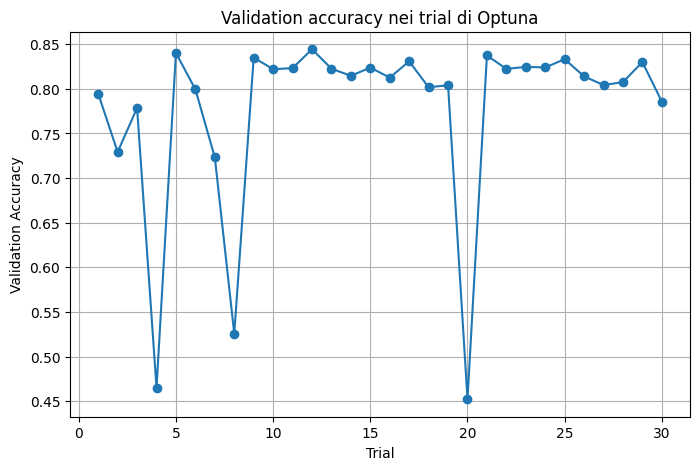

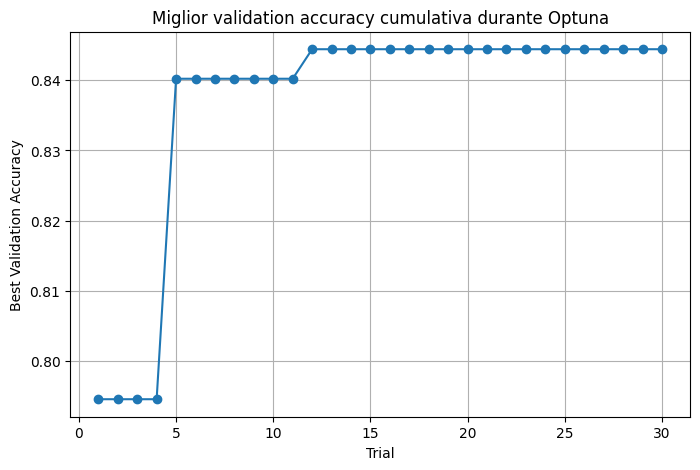

In [ ]:
# Accuracy di ogni trial
trial_values = [trial.value for trial in study.trials if trial.value is not None]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(trial_values) + 1), trial_values, marker="o")
plt.title("Validation accuracy nei trial di Optuna")
plt.xlabel("Trial")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

# Best value cumulativo
best_so_far = []
current_best = -np.inf

for value in trial_values:
    if value > current_best:
        current_best = value
    best_so_far.append(current_best)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(best_so_far) + 1), best_so_far, marker="o")
plt.title("Miglior validation accuracy cumulativa durante Optuna")
plt.xlabel("Trial")
plt.ylabel("Best Validation Accuracy")
plt.grid(True)
plt.show()

# 4. Nuova base del modello migliorato

Dopo aver individuato tramite Optuna la configurazione più promettente, costruiamo una nuova versione del modello utilizzando i migliori iperparametri trovati durante il tuning.

La nuova architettura integra:
- **data augmentation migliorata**;
- **Batch Normalization**;
- **Dropout**;
- una struttura convoluzionale più solida, configurata sulla base dei risultati ottenuti da Optuna.

La data augmentation viene inserita all’inizio del modello, in modo che sia applicata solo durante il training.

Rispetto alla versione precedente, oltre alle trasformazioni geometriche già presenti, introduciamo anche leggere variazioni nello spazio colore, come:
- piccole modifiche di **luminosità**;
- leggere variazioni di **contrasto**;
- una lieve alterazione della **saturazione**.

L’obiettivo è rendere il modello meno sensibile a condizioni di luce e colore troppo specifiche del training set, migliorando la robustezza sulle classi più ambigue.

Questa sezione prepara quindi il modello finale da addestrare in modo completo utilizzando la migliore configurazione trovata durante il tuning.

In [ ]:
# 6. Nuova base del modello migliorato con i best params di Optuna

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

# Recupero dei migliori iperparametri trovati
best_params = study.best_trial.params

print("Migliori iperparametri trovati da Optuna:")
for key, value in best_params.items():
    print(f"{key}: {value}")


# Layer custom per leggere variazioni di colore
class ColorJitter(tf.keras.layers.Layer):
    def __init__(self, brightness=0.08, contrast=0.12, saturation=0.10, **kwargs):
        super().__init__(**kwargs)
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def call(self, images, training=None):
        if training is False:
            return images

        images = tf.image.random_brightness(images, max_delta=self.brightness)
        images = tf.image.random_contrast(
            images,
            lower=1.0 - self.contrast,
            upper=1.0 + self.contrast
        )
        images = tf.image.random_saturation(
            images,
            lower=1.0 - self.saturation,
            upper=1.0 + self.saturation
        )
        images = tf.clip_by_value(images, 0.0, 1.0)
        return images


# Data augmentation migliorata
data_augmentation_advanced = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    ColorJitter(brightness=0.08, contrast=0.12, saturation=0.10)
], name="data_augmentation_advanced")


def build_final_model_from_optuna(best_params, input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Input(shape=input_shape),

        data_augmentation_advanced,

        Conv2D(best_params["filters_1"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(best_params["filters_1"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(best_params["dropout_1"]),

        Conv2D(best_params["filters_2"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(best_params["filters_2"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(best_params["dropout_2"]),

        Conv2D(best_params["filters_3"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(best_params["filters_3"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(best_params["dropout_3"]),

        Conv2D(best_params["filters_4"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(best_params["filters_4"], (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(best_params["dropout_4"]),

        GlobalAveragePooling2D(),
        Dense(best_params["dense_units"], activation="relu"),
        BatchNormalization(),
        Dropout(best_params["dropout_dense"]),
        Dense(num_classes, activation="softmax")
    ], name="cifar10_final_model_optuna")

    return model


final_model = build_final_model_from_optuna(best_params)
final_model.summary()

Migliori iperparametri trovati da Optuna:
filters_1: 64
filters_2: 96
filters_3: 128
filters_4: 192
dropout_1: 0.28531417805792
dropout_2: 0.29979579605503115
dropout_3: 0.303433816762043
dropout_4: 0.49804173858610157
dropout_dense: 0.30697684582085305
dense_units: 128
learning_rate: 0.003494091527195516


Model: "cifar10_final_model_optuna"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_advanced      │ (None, 32, 32, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 192)      │       221,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 4, 4, 192)      │           768 │
│ (BatchNormalization)            │                        │             

 Total params: 1,019,146 (3.89 MB)

 Trainable params: 1,016,970 (3.88 MB)

 Non-trainable params: 2,176 (8.50 KB)

# 5. Training del modello finale

Dopo aver costruito il modello finale utilizzando la configurazione migliore trovata durante il tuning, procediamo con l’addestramento completo.

Come già introdotto nel modello base, le callback ci aiutano a controllare meglio il training:
- **EarlyStopping** interrompe l’addestramento quando la validation loss non migliora più per un certo numero di epoche, evitando training inutilmente lunghi e riducendo il rischio di overfitting;
- **ReduceLROnPlateau** riduce automaticamente il learning rate quando il modello entra in una fase di stallo temporaneo, favorendo una convergenza più stabile.

In questo modo il modello può sfruttare un numero massimo elevato di epoche, mantenendo però un comportamento adattivo durante l’addestramento.

In [ ]:
# 7. Training del modello finale

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

final_model.compile(
    optimizer=Adam(learning_rate=best_params["learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = final_model.fit(
    x_train,
    y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.3084 - loss: 1.9813 - val_accuracy: 0.3420 - val_loss: 2.0078 - learning_rate: 0.0035
Epoch 2/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.5293 - loss: 1.3096 - val_accuracy: 0.4792 - val_loss: 1.7299 - learning_rate: 0.0035
Epoch 3/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.6231 - loss: 1.0723 - val_accuracy: 0.6028 - val_loss: 1.3488 - learning_rate: 0.0035
Epoch 4/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.6771 - loss: 0.9263 - val_accuracy: 0.6838 - val_loss: 0.9803 - learning_rate: 0.0035
Epoch 5/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7118 - loss: 0.8339 - val_accuracy: 0.6638 - val_loss: 1.0528 - learning_rate: 0.0035
Epoch 6/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7355 - loss: 0.7721 - val_accuracy: 0.7806 - val_loss: 0.6363 - learning_rate: 0.0035
Epoch 7/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7

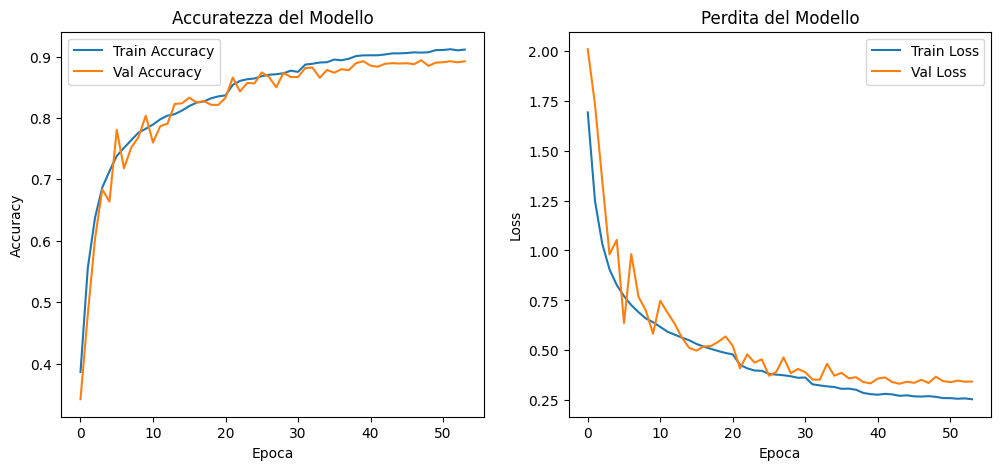

In [ ]:
# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = final_model.evaluate(x_test, y_test)
print(f'Perdita sul test set: {test_loss:.4f}')
print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8850 - loss: 0.3497
Perdita sul test set: 0.3509
Accuratezza sul test set: 0.8830


# 6. Esportazione del modello finale

Una volta completato l’addestramento, il modello finale può essere salvato su file per essere riutilizzato in seguito senza dover ripetere il training.

In questo progetto utilizziamo il formato **`.keras`**, che rappresenta il formato nativo di salvataggio di Keras. Questo permette di conservare in un unico file:
- l’architettura del modello;
- i pesi appresi durante l’addestramento;
- la configurazione necessaria per il riutilizzo del modello.

Il salvataggio del modello è utile sia per future analisi, sia per un’eventuale integrazione in un’applicazione esterna o in una piccola demo di presentazione del progetto.

In [ ]:
import tensorflow as tf
import keras
from keras import layers

# ============================================================
# 1. Definizione "Parlante" e Serializzabile del Layer Custom
# ============================================================
@keras.saving.register_keras_serializable(package="Custom")
class ColorJitter(layers.Layer):
    def __init__(self, brightness=0.08, contrast=0.12, saturation=0.10, **kwargs):
        super().__init__(**kwargs)
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def call(self, x, training=None):
        # L'augmentation si disattiva automaticamente se training=False
        if training is False or training is None:
            return x

        # Logica di trasformazione (solo in training)
        x = tf.image.random_brightness(x, max_delta=self.brightness)
        x = tf.image.random_contrast(x, lower=1.0 - self.contrast, upper=1.0 + self.contrast)
        x = tf.image.random_saturation(x, lower=1.0 - self.saturation, upper=1.0 + self.saturation)
        return tf.clip_by_value(x, 0.0, 1.0)

    def get_config(self):
        # Fondamentale per il salvataggio nel formato .keras
        config = super().get_config()
        config.update({
            "brightness": self.brightness,
            "contrast": self.contrast,
            "saturation": self.saturation,
        })
        return config

# ============================================================
# 2. Verifica del Modello Esistente
# ============================================================
if "final_model" not in globals():
    raise ValueError(
        "La variabile 'final_model' non esiste. Assicurati di aver addestrato il modello in questa sessione."
    )

print(f"--- Modello rilevato: {final_model.name} ---")

# ============================================================
# 3. Esportazione Diretta (Standard 2026)
# ============================================================
# Grazie a register_keras_serializable, possiamo salvare il modello INTERO.
# Non serve più "strippare" i layer manualmente: in produzione basterà
# passare la classe ColorJitter come custom_object.

export_path = "mio_modello_completo.keras"

# Salviamo il modello originale (che include il ColorJitter)
final_model.save(export_path)

print(f"\n✅ Successo! Modello salvato in: {export_path}")
print("Nota: Il file .keras ora contiene la 'ricetta' per il ColorJitter.")

# ============================================================
# 4. Test Rapido di Caricamento (Simulazione Produzione)
# ============================================================
try:
    reloaded_model = keras.models.load_model(
        export_path,
        custom_objects={"ColorJitter": ColorJitter}
    )

    # Test forward pass per conferma
    input_shape = final_model.input_shape[1:]
    dummy_input = tf.zeros((1,) + input_shape)
    _ = reloaded_model(dummy_input, training=False)

    print("\n🔥 Test di ricaricamento superato: il modello è pronto per Streamlit/App!")
except Exception as e:
    print(f"\n❌ Errore durante il test di ricaricamento: {e}")

--- Modello rilevato: cifar10_final_model_optuna ---

✅ Successo! Modello salvato in: mio_modello_completo.keras
Nota: Il file .keras ora contiene la 'ricetta' per il ColorJitter.

🔥 Test di ricaricamento superato: il modello è pronto per Streamlit/App!


In [ ]:
import time

def stampa_ciao():
    print("Inizio dello script... stampo ogni 60 secondi.")
    try:
        while True:
            print("ciao")
            # Attende 60 secondi prima della prossima esecuzione
            time.sleep(60)
    except KeyboardInterrupt:
        print("\nScript interrotto dall'utente. Alla prossima!")

if __name__ == "__main__":
    stampa_ciao()

Inizio dello script... stampo ogni 60 secondi.
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
ciao
